# 03 · The racing line

The minimum-curvature line: a **quadratic program over the lateral offset** `n(s)` inside the
corridor. Curvature is (locally) linear in the offsets, so minimising ∫κ² subject to the
corridor bounds is a sparse QP — solved in tens of milliseconds for a full lap. Minimum curvature ≈
maximum cornering speed for a grip-limited car, and the result is itself a first-class track.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "crates").is_dir():
            return p
    raise RuntimeError("run this notebook from inside the outlap repository")


ROOT = _find_root(Path.cwd())

# Validated reference palette (light mode) — same style as the tour notebook.
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e7e6e2"
BLUE, AQUA, RED = "#2a78d6", "#1baf7a", "#e34948"
LOADS5 = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]  # ordinal, 5 steps
SEQ = LinearSegmentedColormap.from_list(
    "outlap_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)

mpl.rcParams.update(
    {
        "figure.dpi": 115, "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
        "axes.titlesize": 12, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": INK2, "ytick.color": INK2, "font.size": 10.5,
        "legend.frameon": False, "lines.linewidth": 2.0,
    }
)

try:
    import ipywidgets as widgets  # noqa: F401

    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    print("ipywidgets not installed - interactive panels are skipped "
          "(uv sync --group notebooks)")

from outlap.core import Track, min_curvature, solve_lap_dataset, track_dataset

VEH = str(ROOT / "data" / "vehicles" / "f1_2026")
track = Track.load(str(ROOT / "data" / "tracks" / "catalunya"))
ds = track_dataset(track, ds_m=2.0)

HW, MARGIN = 1.1, 0.3  # car half-width and safety margin, m
rl = min_curvature(track, half_width_m=HW, margin_m=MARGIN)
print(f"stations: {len(rl.s())} at ds = {rl.ds_m} m")

stations: 2339 at ds = 2.0 m


## The offsets, inside their bounds

The QP's decision variable is the signed lateral offset at each station; the corridor bounds
(width − half-width − margin) are the constraints. Where the solution rides a bound, the car
is using every centimetre of road:

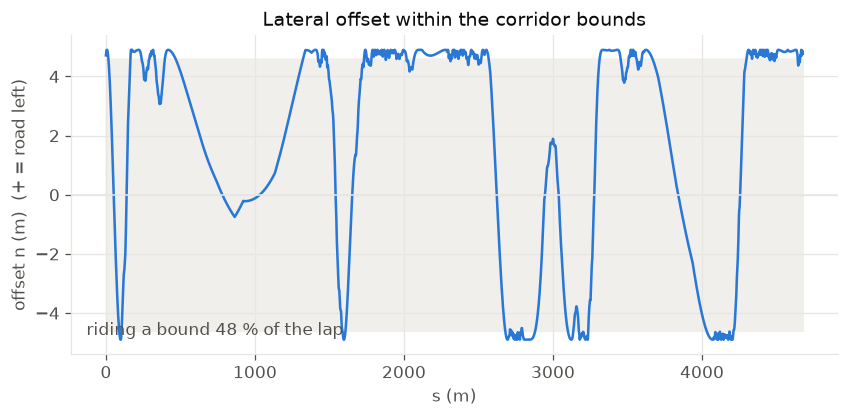

In [2]:
srl, n = rl.s(), rl.n()
wl = np.interp(srl, ds.s.to_numpy(), ds.width_left.to_numpy()) - HW - MARGIN
wr = np.interp(srl, ds.s.to_numpy(), ds.width_right.to_numpy()) - HW - MARGIN

fig, ax = plt.subplots(figsize=(8.6, 3.6))
ax.fill_between(srl, -wr, wl, color="#f0efec")
ax.plot(srl, n, color=BLUE, lw=1.6)
ax.axhline(0, color=GRID, lw=1)
ax.set_xlabel("s (m)")
ax.set_ylabel("offset n (m)  (+ = road left)")
ax.set_title("Lateral offset within the corridor bounds")
at_bound = np.mean((n > wl - 0.05) | (n < -wr + 0.05)) * 100
ax.text(0.02, 0.06, f"riding a bound {at_bound:.0f} % of the lap",
        transform=ax.transAxes, color=INK2)
plt.show()

## What it buys: curvature down, speed up

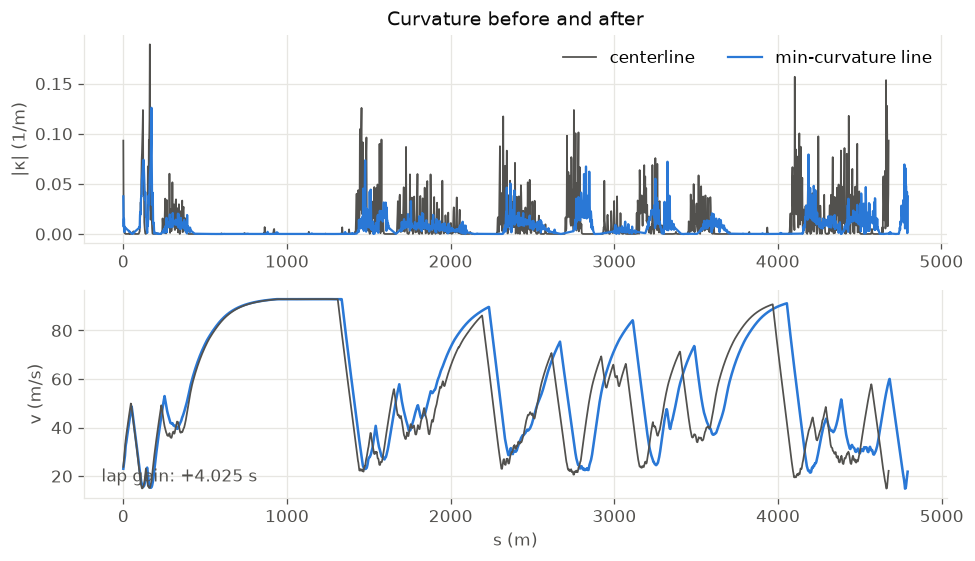

In [3]:
line_ds = track_dataset(rl.line(), ds_m=2.0)
kc = np.abs(ds.kappa_h.to_numpy())
kr = np.abs(line_ds.kappa_h.to_numpy())

lap_c = solve_lap_dataset(VEH, track)
lap_r = solve_lap_dataset(VEH, rl)
gain = lap_c.attrs["lap_time_s"] - lap_r.attrs["lap_time_s"]
assert gain > 0, "the racing line must beat the centerline"

fig, (a, b) = plt.subplots(2, 1, figsize=(8.6, 5.0), sharex=False)
a.plot(ds.s, kc, color=INK2, lw=1.1, label="centerline")
a.plot(line_ds.s, kr, color=BLUE, lw=1.4, label="min-curvature line")
a.set_ylabel("|κ| (1/m)")
a.legend(ncols=2)
a.set_title("Curvature before and after")
b.plot(lap_r.s, lap_r.v, color=BLUE, lw=1.6)
b.plot(lap_c.s, lap_c.v, color=INK2, lw=1.1)
b.set_xlabel("s (m)")
b.set_ylabel("v (m/s)")
b.text(0.02, 0.08, f"lap gain: {gain:+.3f} s", transform=b.transAxes, color=INK2)
plt.tight_layout()
plt.show()

## A surprise: narrower corridors aren't always slower

Sweep the assumed half-width. Intuition says a wider car (less corridor) must be slower — but
minimum **curvature** is not minimum **time**: with lots of room, the QP happily spends extra
*path length* to buy straighter geometry, and at T0 that trade can lose more than it gains.
Clamping the corridor forces a shorter line. The lesson is real and worth knowing: the
min-curvature line is an excellent heuristic, not an optimum — the free-trajectory optimal-lap
solver is a later milestone.

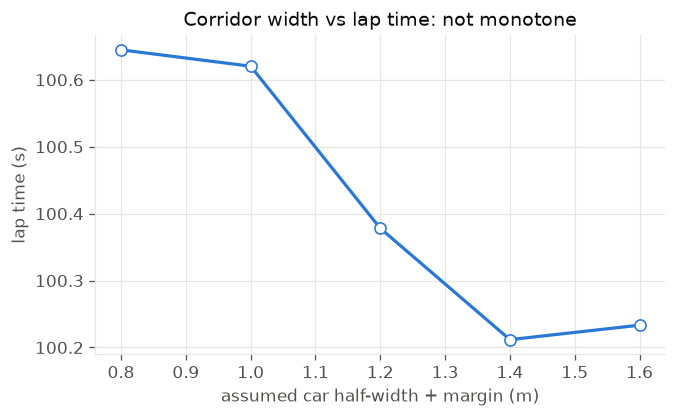

  0.8 m → 100.645 s   1.0 m → 100.620 s   1.2 m → 100.378 s   1.4 m → 100.212 s   1.6 m → 100.233 s


In [4]:
hws = [0.8, 1.0, 1.2, 1.4, 1.6]
times = []
for hw in hws:
    r = min_curvature(track, half_width_m=hw)
    times.append(solve_lap_dataset(VEH, r).attrs["lap_time_s"])

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(hws, times, "-o", color=BLUE, ms=7, mfc="white", mec=BLUE)
ax.set_xlabel("assumed car half-width + margin (m)")
ax.set_ylabel("lap time (s)")
ax.set_title("Corridor width vs lap time: not monotone")
plt.show()
print("  " + "   ".join(f"{h:.1f} m → {t:.3f} s" for h, t in zip(hws, times)))

> **▶ Interactive.** The next cell is live only in a running Jupyter (`uv sync --group notebooks`,
> then `uv run --with jupyterlab jupyter lab`). On GitHub you're seeing its static twin above.

interactive(children=(FloatSlider(value=1.1, description='half-width', max=1.8, min=0.6), FloatSlider(value=0.…

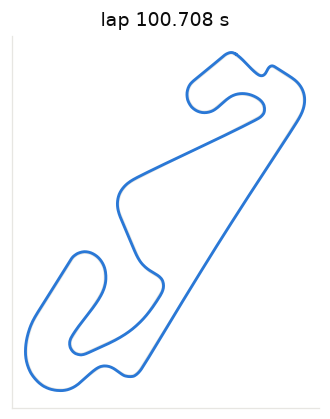

In [5]:
if HAVE_WIDGETS:

    @widgets.interact(
        hw=widgets.FloatSlider(min=0.6, max=1.8, step=0.1, value=1.1, description="half-width"),
        margin=widgets.FloatSlider(min=0.0, max=1.0, step=0.1, value=0.3, description="margin"),
    )
    def line_lab(hw: float, margin: float) -> None:
        r = min_curvature(track, half_width_m=hw, margin_m=margin)
        lap = solve_lap_dataset(VEH, r)
        lds = track_dataset(r.line(), ds_m=4.0)
        fig, ax = plt.subplots(figsize=(6.8, 4.2))
        ax.plot(ds.x, ds.y, color=GRID, lw=1)
        ax.plot(lds.x, lds.y, color=BLUE, lw=1.8)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"lap {lap.attrs['lap_time_s']:.3f} s")
        plt.show()

    line_lab(1.1, 0.3)  # direct call: a real error here must fail CI

**Next:** [04 · the T0 lap solver](04_t0_lap.ipynb) — what happens between the line and the
lap time.